I will be using this notebook as a Slide Deck for my research.

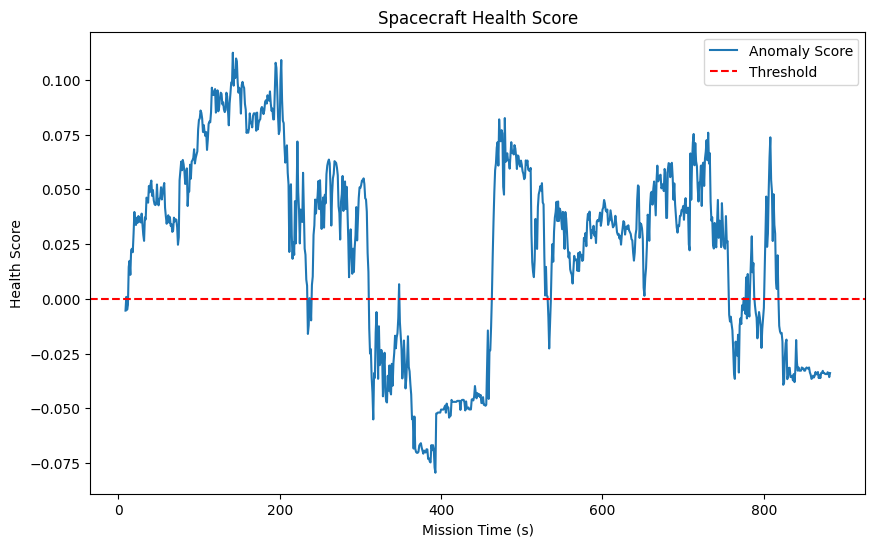

In [25]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

train_df = pd.read_csv("../datasets/clean.csv")
test_df = pd.read_csv("../datasets/o2_leak.csv")

# then select the features
features = ["pitch", "y_pos", "z_pos", "o2_level", "co2_level", "total_drain", "solar_input", "is_scrubber_on", "is_engine_on"]
X_train = train_df[features]

# initialize Isolation Forest model
model = IsolationForest(contamination=0.01, random_state=42)

# train model
model.fit(X_train)

X_test = test_df[features]
test_df['scores'] = model.decision_function(X_test)
test_df['anomaly_pred'] = model.predict(X_test)

# visualize results
plt.figure(figsize=(10,6))
plt.plot(test_df['timestamp'], test_df['scores'], label='Anomaly Score')
plt.axhline(y=0, color='r', linestyle='--', label='Threshold')
plt.title("Spacecraft Health Score")
plt.xlabel("Mission Time (s)")
plt.ylabel("Health Score")
plt.legend()
plt.show()

In [21]:
pd.set_option('display.max_rows', 300)
print(test_df[test_df['scores'] < 0][['timestamp', 'o2_level', 'scores', 'anomaly_pred']])

     timestamp  o2_level    scores  anomaly_pred
0            9    99.964 -0.005407            -1
2           11    99.956 -0.004996            -1
3           12    99.952 -0.002827            -1
226        235    99.060 -0.016054            -1
227        236    99.056 -0.012074            -1
229        238    99.048 -0.000473            -1
230        239    99.044 -0.009863            -1
302        311    98.756 -0.013464            -1
303        312    98.752 -0.025020            -1
304        313    98.748 -0.022993            -1
305        314    98.744 -0.036039            -1
306        315    98.740 -0.042843            -1
307        316    98.736 -0.055125            -1
308        317    98.732 -0.033979            -1
309        318    98.728 -0.036118            -1
310        319    98.724 -0.015536            -1
311        320    98.720 -0.006083            -1
312        321    98.716 -0.016613            -1
313        322    98.712 -0.036560            -1
314        323    98

In [24]:
fp_rows = test_df[(test_df['is_anomaly'] == 0) & (test_df['anomaly_pred'] == -1)]
fp_count = len(fp_rows)

healthy_rows = len(test_df[test_df['is_anomaly'] == 0])

if healthy_rows > 0:
    print(fp_count / healthy_rows)

0.29523809523809524


Working with separate features list for better understanding of data

In [ ]:
agents = {
    "ECLSS": ["o2_level", "co2_level", "is_scrubber_on"],
    "EPS": ["total_drain", "solar_input", "is_engine_on", "is_scrubber_on"],
    "GNC": ["pitch", "y_pos", "z_pos"]
}

for name, list in agents.items():
    model = IsolationForest(contamination=0.01, random_state=42)
    model.fit(train_df[list])

    test_df[f"{name}_score"] = model.decision_function(test_df[list])

Adding a Standard Scaler so the model can see data as distance from mean instead of raw numbers (5000W, 20% o2 level, 2 pitch degrees)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_trained_scaled = scaler.fit_transform(train_df[agents['ECLSS']])
model.fit(X_trained_scaled)

X_test_scaled = scaler.transform(test_df[agents['ECLSS']])

view_cols = ['timestamp', 'ECLSS_score', 'EPS_score', 'GNC_score', 'is_anomaly']
print(test_df[test_df['is_anomaly'] == 1][view_cols].head(100))

     timestamp  ECLSS_score  EPS_score  GNC_score  is_anomaly
420        429     0.157382  -0.024129  -0.068030           1
421        430     0.156509  -0.024129  -0.065683           1
422        431     0.157944  -0.024129  -0.067354           1
423        432     0.158598  -0.024129  -0.065683           1
424        433     0.154931  -0.024129  -0.065166           1
425        434     0.153952  -0.024129  -0.066066           1
426        435     0.153596  -0.024129  -0.065166           1
427        436     0.147879  -0.024129  -0.064335           1
428        437     0.142736  -0.024129  -0.064335           1
429        438     0.145365  -0.024129  -0.068030           1
430        439     0.147659  -0.024129  -0.068030           1
431        440     0.142822  -0.024129  -0.068030           1
432        441     0.142919  -0.024129  -0.065168           1
433        442     0.147166  -0.024129  -0.065168           1
434        443     0.149786  -0.024129  -0.064438           1
435     

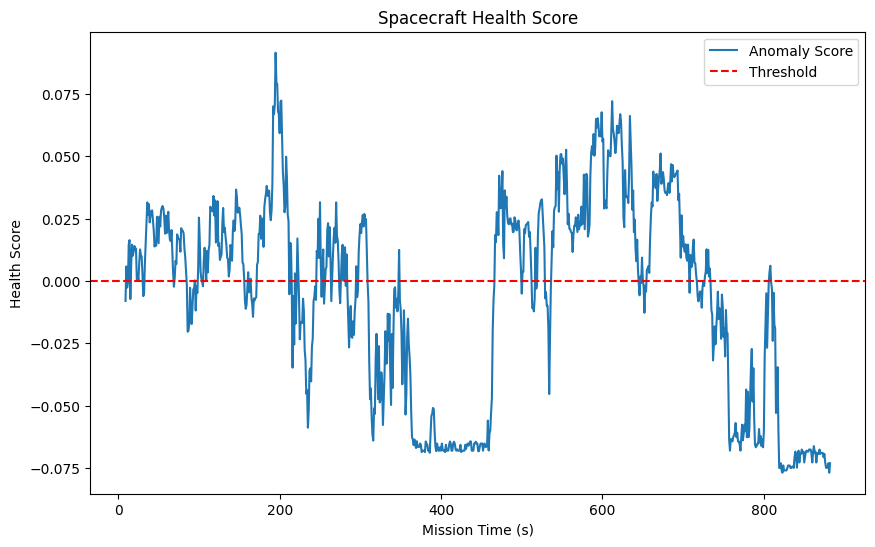

In [35]:
plt.figure(figsize=(10,6))
plt.plot(test_df['timestamp'], test_df['GNC_score'], label='Anomaly Score')
plt.axhline(y=0, color='r', linestyle='--', label='Threshold')
plt.title("Spacecraft Health Score")
plt.xlabel("Mission Time (s)")
plt.ylabel("Health Score")
plt.legend()
plt.show()